In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [81]:
df=pd.read_csv('../dataset/Loan_default.csv')

In [82]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [83]:
df.drop('LoanID', axis=1, inplace= True)

In [84]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].unique())

["Bachelor's" "Master's" 'High School' 'PhD']
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
['Divorced' 'Married' 'Single']
['Yes' 'No']
['Yes' 'No']
['Other' 'Auto' 'Business' 'Home' 'Education']
['Yes' 'No']


In [88]:
from sklearn.preprocessing import LabelEncoder



In [89]:
df.select_dtypes(include='object').columns

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

In [90]:
from sklearn.preprocessing import LabelEncoder

education_encoder = LabelEncoder()
employment_encoder = LabelEncoder()
maritalStatus_encoder = LabelEncoder() 
hasmortgage_encoder = LabelEncoder()
loanpurpose_encoder = LabelEncoder()
hascosigner_encoder = LabelEncoder()
HasDependents_encoder = LabelEncoder()

In [91]:
df['Education_encoded'] = education_encoder.fit_transform(df['Education'])
df['Employment_encoded'] = employment_encoder.fit_transform(df['EmploymentType'])
df['marital_status_encoded'] = maritalStatus_encoder.fit_transform(df['MaritalStatus'])
df['hasmortagage_encoded'] = hasmortgage_encoder.fit_transform(df['HasMortgage'])
df['loanpurpose_encoded'] = loanpurpose_encoder.fit_transform(df['LoanPurpose'])
df['hascosigner_encoded'] = hascosigner_encoder.fit_transform(df['HasCoSigner'])
df['HasDependents_encoded'] = HasDependents_encoder.fit_transform(df['HasDependents'])

In [92]:
df.select_dtypes(exclude='object').columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default',
       'Education_encoded', 'Employment_encoded', 'marital_status_encoded',
       'hasmortagage_encoded', 'loanpurpose_encoded', 'hascosigner_encoded',
       'HasDependents_encoded'],
      dtype='object')

In [93]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [94]:
df1=pd.DataFrame(scaler.fit_transform(df[['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed','NumCreditLines', 'InterestRate', 'LoanTerm']]),columns=['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed','NumCreditLines', 'InterestRate', 'LoanTerm'])

In [95]:
df2 = df[[
    'Default', 
    'Education_encoded',
    'marital_status_encoded', 
    'Employment_encoded', 
    'hasmortagage_encoded',
    'HasDependents_encoded', 
    'loanpurpose_encoded',
    'hascosigner_encoded'
]]

In [96]:
new_df=pd.concat([df1,df2], axis=1)

In [97]:
new_df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'Default',
       'Education_encoded', 'marital_status_encoded', 'Employment_encoded',
       'hasmortagage_encoded', 'HasDependents_encoded', 'loanpurpose_encoded',
       'hascosigner_encoded'],
      dtype='object')

In [98]:
x=new_df[['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm',
       'Education_encoded', 'Employment_encoded', 'marital_status_encoded',
       'hasmortagage_encoded', 'loanpurpose_encoded', 'hascosigner_encoded',
       'HasDependents_encoded']]

In [99]:
y=new_df['Default']

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
x_train, x_test, y_train,y_test= train_test_split(x,y, random_state=42, test_size=0.2)

In [102]:
from sklearn.linear_model import LogisticRegression
lgr=LogisticRegression()

In [103]:
lgr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [116]:
print(x_train.shape)

(204277, 15)


In [104]:
y_pred=lgr.predict(x_test)

In [105]:
print(confusion_matrix(y_test, y_pred))
df['Default'].value_counts()

[[45060   110]
 [ 5724   176]]


Default
0    225694
1     29653
Name: count, dtype: int64

In [106]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.62      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.75      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



In [107]:
y_pred_prob= lgr.predict_proba(x_test)[:,1]

In [108]:
fpr,tpr,thre= roc_curve(y_test,y_pred_prob)

roc_auc_score(y_test,y_pred_prob)

0.7489896211299685

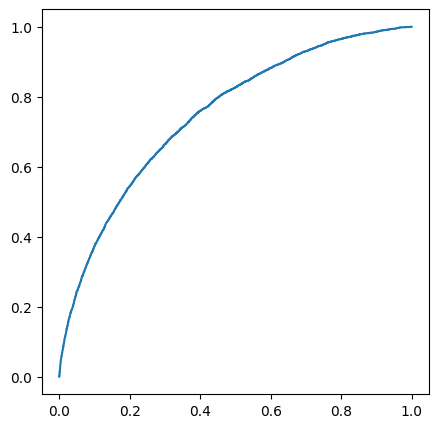

In [109]:
plt.figure(figsize=(5,5))
plt.plot(fpr,tpr)
plt.show()

In [110]:
import joblib

In [111]:
joblib.dump(lgr,'logistic_regression.pkl')


['logistic_regression.pkl']

In [112]:
new_df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'Default',
       'Education_encoded', 'marital_status_encoded', 'Employment_encoded',
       'hasmortagage_encoded', 'HasDependents_encoded', 'loanpurpose_encoded',
       'hascosigner_encoded'],
      dtype='object')

In [113]:
import joblib

# Using '../' so they save right next to app.py instead of hidden inside the notebook folder
joblib.dump(education_encoder, '../Education_encoder.pkl')
joblib.dump(employment_encoder, '../employment_encoder.pkl')
joblib.dump(maritalStatus_encoder, '../maritalStatus_encoder.pkl')
joblib.dump(hasmortgage_encoder, '../hasmortgage_encoder.pkl')
joblib.dump(loanpurpose_encoder, '../loanpurpose_encoder.pkl')
joblib.dump(hascosigner_encoder, '../hascosigner_encoder.pkl')
joblib.dump(HasDependents_encoder, '../HasDependents_encoder.pkl')

joblib.dump(scaler, '../scaler.pkl')
joblib.dump(lgr, '../model.pkl')

['../model.pkl']

In [119]:
print(education_encoder.classes_)
print(employment_encoder.classes_)
print(maritalStatus_encoder.classes_)
print(hasmortgage_encoder.classes_)
print(loanpurpose_encoder.classes_)
print(hascosigner_encoder.classes_)
print(HasDependents_encoder.classes_)

["Bachelor's" 'High School' "Master's" 'PhD']
['Full-time' 'Part-time' 'Self-employed' 'Unemployed']
['Divorced' 'Married' 'Single']
['No' 'Yes']
['Auto' 'Business' 'Education' 'Home' 'Other']
['No' 'Yes']
['No' 'Yes']


In [120]:
print(x_train.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'Education_encoded',
       'Employment_encoded', 'marital_status_encoded', 'hasmortagage_encoded',
       'loanpurpose_encoded', 'hascosigner_encoded', 'HasDependents_encoded'],
      dtype='object')


In [122]:
import joblib

model = joblib.load("../model.pkl")

print(model.n_features_in_)

try:
    print(model.feature_names_in_)
except:
    print("No feature names stored")

15
['Age' 'Income' 'LoanAmount' 'CreditScore' 'MonthsEmployed'
 'NumCreditLines' 'InterestRate' 'LoanTerm' 'Education_encoded'
 'Employment_encoded' 'marital_status_encoded' 'hasmortagage_encoded'
 'loanpurpose_encoded' 'hascosigner_encoded' 'HasDependents_encoded']


In [123]:
import joblib

scaler = joblib.load("../scaler.pkl")

print(scaler.n_features_in_)

try:
    print(scaler.feature_names_in_)
except:
    print("No feature names stored")

8
['Age' 'Income' 'LoanAmount' 'CreditScore' 'MonthsEmployed'
 'NumCreditLines' 'InterestRate' 'LoanTerm']
